# Reconstruction roll-off

A DAC needs to "fill in" the data in between the samples provided to it in order to produce a continuous waveform. It can be shown (see, e.g., Kalfus et al. IEEE TQE 2020) that this effect is manifested as a frequency-dependent attenuation of the DAC output power. However, some DACs have the ability to let the user select the method with which samples are filled in. The two most common are non-return-to-zero (NRZ), wherein the DAC output is constant in between samples, and mix-mode, wherein the DAC inverts the output signal halfway in between two sample points. The effect is that power can be selectively distributed among different frequency bands depending on the range desired.

The bands that influence this effect are defined solely in terms of the DAC's Nyquist zones, each of which has a bandwidth equal to half the sampling rate. The default Acadia software allows the user to choose the DAC sampling rate so as to optimize the locations of signals within Nyquist zones; this is desirable both for maximizing output power and for filtering out image tones in other Nyquist zones.

Depending on the firmware image used, there is a discrete set of sampling rates that one can choose from. Below, we plot the roll-off due to DAC reconstruction available for each choice of firmware image.

/tmp/ipykernel_2152147/3153166303.py:28: RuntimeWarning: divide by zero encountered in log10
  20*np.log10(att),
/tmp/ipykernel_2152147/3153166303.py:28: RuntimeWarning: divide by zero encountered in log10
  20*np.log10(att),
/tmp/ipykernel_2152147/3153166303.py:28: RuntimeWarning: divide by zero encountered in log10
  20*np.log10(att),
/tmp/ipykernel_2152147/3153166303.py:28: RuntimeWarning: divide by zero encountered in log10
  20*np.log10(att),
/tmp/ipykernel_2152147/3153166303.py:28: RuntimeWarning: divide by zero encountered in log10
  20*np.log10(att),
/tmp/ipykernel_2152147/3153166303.py:28: RuntimeWarning: divide by zero encountered in log10
  20*np.log10(att),
/tmp/ipykernel_2152147/3153166303.py:28: RuntimeWarning: divide by zero encountered in log10
  20*np.log10(att),
/tmp/ipykernel_2152147/3153166303.py:28: RuntimeWarning: divide by zero encountered in log10
  20*np.log10(att),
/tmp/ipykernel_2152147/3153166303.py:28: RuntimeWarning: divide by zero encountered in log10
  2

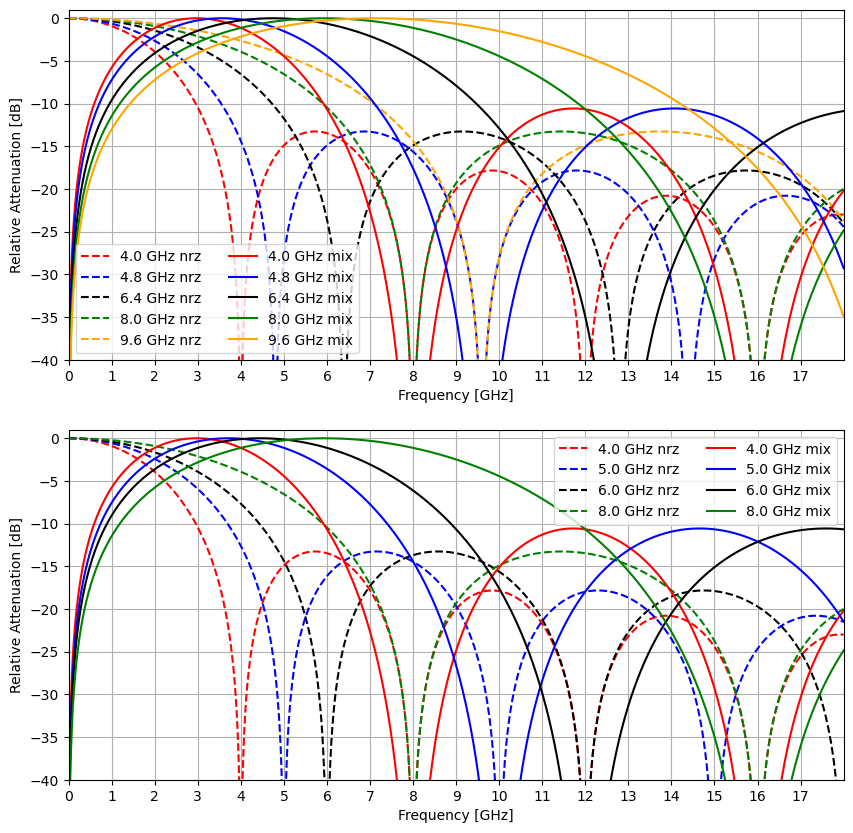

In [6]:
import numpy as np
import matplotlib.pyplot as plt

freqs = np.linspace(0, 18, 10001)

def nrz(f,fs):
    return (1/fs)*np.exp(-1j*np.pi*f/fs)*np.sinc(f/fs)

def mix(f,fs):
    return 1j*(1/fs)*np.exp(-1j*np.pi*f/fs)*np.sin(np.pi*f/(2*fs))*np.sinc(f/(2*fs))

colors = ["red", "blue", "black", "green", "orange", "purple", "pink", "brown"]
fig,ax = plt.subplots(2,1,figsize=(10,10))

interpolations = [[5,6,8,10,12], [4,5,6,8]]

for idx_interface_freq,interface_freq in enumerate([0.2,0.25]):

    # 4 samples are presented to the DAC each clock cycle
    sampling_rates = [round(interface_freq*4*interpolation,1) for interpolation in interpolations[idx_interface_freq]]

    for profile,name,linestyle in [(nrz,"nrz","--"), (mix,"mix","-")]:
        for idx_rate,rate in enumerate(sampling_rates):
            att = np.abs(profile(freqs, rate))
            att /= np.max(att)
            ax[idx_interface_freq].plot(
                freqs, 
                20*np.log10(att),
                linestyle=linestyle,
                color=colors[idx_rate],
                label=f"{rate} GHz {name}"
            )
        
    ax[idx_interface_freq].legend(ncol=2)
    ax[idx_interface_freq].grid()
    ax[idx_interface_freq].set_xticks(np.arange(18))
    ax[idx_interface_freq].set_xlabel("Frequency [GHz]")
    ax[idx_interface_freq].set_ylabel("Relative Attenuation [dB]")
    ax[idx_interface_freq].set_ylim(-40,1)
    ax[idx_interface_freq].set_xlim(0, 18)

# Filtering

In [2]:
urls = [
    "https://www.minicircuits.com/pages/s-params/VBF-7200+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/VBF-7331+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/VBF-7500+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/VBF-7700+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/VBF-7900+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/VBF-2900+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/VBF-4440+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/SLP-2950+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/SLP-2400+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/VLF-2250+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/VLF-2350+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/VLF-4400+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/VLFG-2000+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/VLFG-2250+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/VLFG-2275+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/VLFG-3800+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/VLFG-4800+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/ZLFW-K5000+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/ZXLF-K172H+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/ZXLF-K192+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/VHF-3800+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/VHF-7150+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/ZHFG-K3800+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/ZHFG-K4000+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/ZHFW-K5000+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/VBFZ-3590-S+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/VBFZ-5500-S+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/VBFZ-6260-S+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/VHF-6010+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/VBFZ-4000-S+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/VBF-8650+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/VHF-8400+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/VHF-5500+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/VBF-8450+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/VLF-7200+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/VLF-8400+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/VLF-6400+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/VLFG-3000+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/VLFG-2500+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/VLFG-3400+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/VHF-5050+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/VHF-4600+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/ZHFG-K4400+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/ZHFW-K1132+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/ZHFW-K133+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/ZHFW-K1042+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/ZHFW-K9500+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/ZHFW-K7500+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/ZHFW-K7000+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/ZHSSM-8G-S+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/ZLFV-K1452+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/ZLFV-K1552+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/ZLFV-K1652+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/ZLFW-K113+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/ZLFW-K123+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/ZLFW-K143+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/ZLFW-K1292+_S2P.zip",
    "https://www.minicircuits.com/pages/s-params/ZLSS-14G-S+_S2P.zip"
    ]

from urllib.request import urlretrieve
from zipfile import ZipFile

for url in urls:
    filename,message = urlretrieve(url)
    with ZipFile(filename, "r") as zipfile:
        zipfile.extractall("/tmp/filters")
    

HTTPError: HTTP Error 504: Gateway Time-out

In [3]:
import os 
import shutil

# Clean up the files
# first, expand any directories
for filename in os.listdir("/tmp/filters"):
    fullpath = os.path.join("/tmp/filters", filename)
    if os.path.isdir(fullpath):
        for subfile in os.listdir(fullpath):
            shutil.move(os.path.join(fullpath, subfile), os.path.join("/tmp/filters", subfile))
        shutil.rmtree(fullpath)

# Go through again, remove files not at 25C and rename 
for filename in os.listdir("/tmp/filters"):
    fullpath = os.path.join("/tmp/filters", filename)
    if ("Minus" in filename) or ("Plus" in filename and "Plus25" not in filename):
        os.remove(fullpath)
    elif "-S+" in filename:
        shutil.move(fullpath, fullpath[:fullpath.index("-S+")] + ".s2p")
    elif "+" in filename:
        shutil.move(fullpath, fullpath[:fullpath.index("+")] + ".s2p")
    elif ".S2P" in filename:
        shutil.move(fullpath, fullpath[:fullpath.index(".S2P")] + ".s2p")
    else:
        print(f"Did not modify filename {filename}")

In [ ]:
import matplotlib.pyplot as plt
import os
from copy import copy
import numpy as np

sampling_frequencies = [(4.8, "red"), (6.4, "blue"), (8.0, "purple"), (9.6, "green")]
xlim = [2, 18]
xticks = np.arange(xlim[0], xlim[1]+0.001, 1)

for filename in os.listdir("/tmp/filters"):
    s2p_filename = os.path.join("/tmp/filters", filename)
    header = None
    starting_lines = []
    freqs = []
    S11_list = []
    S21_list = []
    S12_list = []
    S22_list = []
    with open(s2p_filename, "r", encoding="latin_1") as s2p:
        for line in s2p:
            if header is None:
                if line.startswith("#"):
                    header = copy(line)
                else:
                    starting_lines.append(line)
                continue
            if line.startswith("!") or len(line.strip()) == 0:
                continue

            # if "\t" in line:
            #     pieces = line.split("\t")
            # else:
            #     pieces = line.split(" ")
            pieces = [p for p in line.split() if len(p.strip()) > 0]

            if "GHZ" in header or "GHz" in header:
                freqs.append(float(pieces[0])*1e9)
            elif "MHZ" in header or "MHz" in header:
                freqs.append(float(pieces[0])*1e6)
            elif "HZ" in header or "Hz" in header:
                freqs.append(float(pieces[0]))
            else:
                raise ValueError(f"Can't find unit in header {header}")

            if "DB" in header or "dB" in header:
                S11 = 10**(float(pieces[1]) / 20) * np.exp(1j*float(pieces[2])*np.pi/180.0)
                S21 = 10**(float(pieces[3]) / 20) * np.exp(1j*float(pieces[4])*np.pi/180.0)
                S12 = 10**(float(pieces[5]) / 20) * np.exp(1j*float(pieces[6])*np.pi/180.0)
                S22 = 10**(float(pieces[7]) / 20) * np.exp(1j*float(pieces[8])*np.pi/180.0)
            elif "RI" in header:
                S11 = float(pieces[1]) + 1j*float(pieces[2])
                S21 = float(pieces[3]) + 1j*float(pieces[4])
                S12 = float(pieces[5]) + 1j*float(pieces[6])
                S22 = float(pieces[7]) + 1j*float(pieces[8])
            else:
                raise ValueError(f"Can't identify format in header {header}")

            S11_list.append(S11)
            S21_list.append(S21)
            S12_list.append(S12)
            S22_list.append(S22)

    freqs = np.array(freqs)
    freqs_GHz = freqs*1e-9
    S = np.array([S11_list, S21_list, S12_list, S22_list])


    fig,ax = plt.subplots(1,len(sampling_frequencies),figsize=(4*len(sampling_frequencies),3), sharey=True)

    for idx,(sampling_frequency,color) in enumerate(sampling_frequencies):
        ax[idx].plot(freqs_GHz, 20*np.log10(np.abs(S[1,:])), c="black")
        nz = 1
        nz_boundary = nz*sampling_frequency/2
        while nz_boundary < freqs_GHz[-1]:
            ax[idx].plot([nz_boundary, nz_boundary], [-100,100], "-", c=color)
            nz += 1
            nz_boundary = nz*sampling_frequency/2

        ax[idx].set_xlabel("Frequency [GHz]")
        ax[idx].grid()
        ax[idx].set_title(f"{filename[:-len('.s2p')]}\nFs={sampling_frequency}", fontsize=10)
        ax[idx].set_xlim(xlim if xlim is not None else [0, freqs_GHz[-1]])
        ax[idx].set_ylim([-50, 0])
        ax[idx].set_yticks(np.arange(-50, 1, 5))
        if xticks is not None:
            ax[idx].set_xticks(xticks)

    ax[0].set_ylabel("|S21| [dB]")


# Plot multiple cascaded filters

In [4]:
import matplotlib.pyplot as plt
import os
from copy import copy
import numpy as np

chain = ["VLFG-2500.s2p",]
sampling_frequencies = [(2.4, "red"), (6.4, "blue"), (8.0, "purple"), (9.6, "green")]
xlim = [2, 10]
points = 1001
interp_freqs = np.linspace(xlim[0], xlim[1], points)
xticks = np.arange(xlim[0], xlim[1]+0.001, 1)

total_S = np.ones((4, points), dtype=np.complex128)

for filename in chain:
    s2p_filename = os.path.join("/tmp/filters", filename)
    header = None
    starting_lines = []
    freqs = []
    S11_list = []
    S21_list = []
    S12_list = []
    S22_list = []
    with open(s2p_filename, "r") as s2p:
        for line in s2p:
            if header is None:
                if line.startswith("#"):
                    header = copy(line)
                else:
                    starting_lines.append(line)
                continue
            if line.startswith("!") or len(line.strip()) == 0:
                continue

            # if "\t" in line:
            #     pieces = line.split("\t")
            # else:
            #     pieces = line.split(" ")
            pieces = [p for p in line.split() if len(p.strip()) > 0]

            if "GHZ" in header or "GHz" in header:
                freqs.append(float(pieces[0])*1e9)
            elif "MHZ" in header or "MHz" in header:
                freqs.append(float(pieces[0])*1e6)
            elif "HZ" in header or "Hz" in header:
                freqs.append(float(pieces[0]))
            else:
                raise ValueError(f"Can't find unit in header {header}")

            if "DB" in header or "dB" in header:
                S11 = 10**(float(pieces[1]) / 20) * np.exp(1j*float(pieces[2])*np.pi/180.0)
                S21 = 10**(float(pieces[3]) / 20) * np.exp(1j*float(pieces[4])*np.pi/180.0)
                S12 = 10**(float(pieces[5]) / 20) * np.exp(1j*float(pieces[6])*np.pi/180.0)
                S22 = 10**(float(pieces[7]) / 20) * np.exp(1j*float(pieces[8])*np.pi/180.0)
            elif "RI" in header:
                S11 = float(pieces[1]) + 1j*float(pieces[2])
                S21 = float(pieces[3]) + 1j*float(pieces[4])
                S12 = float(pieces[5]) + 1j*float(pieces[6])
                S22 = float(pieces[7]) + 1j*float(pieces[8])
            else:
                raise ValueError(f"Can't identify format in header {header}")

            S11_list.append(S11)
            S21_list.append(S21)
            S12_list.append(S12)
            S22_list.append(S22)

    freqs = np.array(freqs)
    freqs_GHz = freqs*1e-9
    S = np.array([S11_list, S21_list, S12_list, S22_list])

    for i in range(4):
        total_S[i,:] *= np.interp(interp_freqs, freqs_GHz, S[i,:])

fig,ax = plt.subplots(1,len(sampling_frequencies),figsize=(4*len(sampling_frequencies),3), sharey=True)

for idx,(sampling_frequency,color) in enumerate(sampling_frequencies):
    ax[idx].plot(interp_freqs, 20*np.log10(np.abs(total_S[1,:])), c="black")
    nz = 1
    nz_boundary = nz*sampling_frequency/2
    while nz_boundary < freqs_GHz[-1]:
        ax[idx].plot([nz_boundary, nz_boundary], [-100,100], "-", c=color)
        nz += 1
        nz_boundary = nz*sampling_frequency/2

    ax[idx].set_xlabel("Frequency [GHz]")
    ax[idx].grid()
    ax[idx].set_title(f"{' -> '.join(chain)}\nFs={sampling_frequency}", fontsize=10)
    ax[idx].set_xlim(xlim if xlim is not None else [0, interp_freqs[-1]])
    ax[idx].set_ylim([-50, 0])
    ax[idx].set_yticks(np.arange(-50, 1, 5))
    if xticks is not None:
        ax[idx].set_xticks(xticks)

ax[0].set_ylabel("|S21| [dB]")


FileNotFoundError: [Errno 2] No such file or directory: '/tmp/filters/VLFG-2500.s2p'